# MODELO PROPHET PARA EL CONTAMINANTE CO PARA MADRID

En este cuaderno, vamos a ajustar modelos Prophet para el contaminante CO sobre la ciudad de Madrid.

Prophet es un software de código abierto desarrollado por Facebook, ahora Meta, en 2017 por Sean J. Taylor y Ben Letham que implementa un procedimiento de predicción que tiene en cuenta tendencias no lineales con múltiples períodos estacionales, como anuales, mensuales, semanales y diarios.

Prophet consiste en un modelo aditivo en el que cada serie temporal se modela como la combinación de un componente de tendencia, un componente estacional, efectos de días festivos y un término de error, que tiene una distribución normal. Matemáticamente, esto se puede expresar como:

$$ y(t) = g(t) + s(t) + h(t) + e_t,$$

donde: 

* $g(t)$ es el componente de tendencia.
* $s(t)$ es el componente estacional.
* $h(t)$ representa los efectos de los días festivos.
* $e_t$ es el término de error, que representa cambios que el modelo no puede explicar.

### Componente de tendencia
Existen dos tipos de componentes de tendencia.

1. **Tendencia lineal**: $g(t) = (k + a(t)^T \delta)t + (m + a(t)^T \gamma),$

donde: 
* $k$ es la tasa de crecimiento.
* $\delta$ es la tasa ajustada.
* $m$ es el parámetro de descompensación.

2. **Tendencia de crecimiento saturado no lineal**: $g(t) = \frac{C}{1 + exp(-k(t-m))},$

donde:
* $C$ es el nivel máximo de saturación.
* $k$ es la tasa de crecimiento. 
* $m$ es un parámetro de compensación.

### Componente estacional

$$
\sum_{n=1}^{N} \left(a_n cos\left(\frac{2 \pi i n}{P}\right) + b_n sin\left(\frac{2 \pi i n}{P}\right)\right),
$$

donde:

* $P$ es la longitud del período estacional en días.
* $N$ es el número de términos en la serie de Fourier.

### Efectos de días festivos

Incorporamos una lista con los días festivos en el modelo, asumiendo que sus efectos son independientes.

Importamos las librerías y definimos las rutas.

In [1]:
import numpy as np
import pandas as pd
import itertools
from sklearn import metrics
from pathlib import Path

from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from prophet.diagnostics import cross_validation, performance_metrics

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("fbprophet").setLevel(logging.WARNING)

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams
plt.style.use("fivethirtyeight")
plt.rcParams["lines.linewidth"] = 1.5
light_style = {
    "figure.facecolor": "#d9effb",   
    "axes.facecolor": "#d9effb",
    "savefig.facecolor": "#d9effb",
    "axes.grid": True,
    "axes.grid.which": "both",
    "axes.spines.left": True,
    "axes.spines.right": True,
    "axes.spines.top": True,
    "axes.spines.bottom": True,
    "grid.color": "#a9d3f2",
    "grid.linewidth": "0.8",
    "text.color": "#333333",
    "axes.labelcolor": "#333333",
    "axes.labelweight": "black",      
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "font.size": 12,
    "axes.titleweight": "bold",      
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
}
plt.rcParams.update(light_style)
rcParams["figure.figsize"] = (18, 7)

c:\Users\Juanfran cd\Desktop\Máster_Ciencia_de_Datos_UA\TFM\TFM_github\tfm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
BASE_PATH = Path("..", "..", "..", "..")
FOLDER_DATA = BASE_PATH / "datasets" / "eda_archivos_cont_clima_indices"
FOLDER_FIGS = BASE_PATH / "figuras" / "Modelado" / "Madrid"
FOLDER_FIGS.mkdir(parents=True, exist_ok=True)

Cargamos los datos.

In [3]:
df = pd.read_csv(FOLDER_DATA / "dataset_cont_clima_indices_limpio.csv")

Filtramos las columnas que realmente necesitamos y como ciudad elegimos únicamente Madrid.

In [4]:
# Listado de columnas seleccionadas
columnas = [
    'Start', 'End', 'CO (mg.m-3)', 'city', 'temperature_2m', 
    'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 
    'surface_pressure', 'cloudcover', 'windspeed_10m', 
    'shortwave_radiation', 'boundary_layer_height', 'NDVI', 'NDBI', 
    'Año', 'Mes', 'Dia', 'Dia_semana', 'Hora',
]

# Filtrar por Madrid y seleccionar las columnas
df1 = df[df['city'] == 'Madrid'][columnas].copy()

# Resetear los índices para que empiecen desde 0
df1.reset_index(drop=True, inplace=True)

## Análisis exploratorio de las estacionalidades

Antes de ajustar el modelo **Prophet**, analizamos si la serie temporal del CO presenta patrones periódicos que se repiten de forma consistente a lo largo del tiempo. Dado que los datos tienen una frecuencia horaria, estudiamos las tres estacionalidades principales que puede incorporar el modelo:

- **Estacionalidad anual:** analizamos la evolución media de la concentración de CO a lo largo de los meses del año.
- **Estacionalidad semanal:** estudiamos el comportamiento medio de la concentración de CO para cada día de la semana.
- **Estacionalidad diaria:** examinamos la evolución media de la concentración de CO durante las 24 horas del día.

Para comprobar no solo la existencia de estos patrones, sino también su estabilidad a lo largo del tiempo, graficamos una curva para cada año. De esta forma, es posible observar si la estructura del patrón mensual, semanal u horario se mantiene de manera aproximada entre los distintos años disponibles, aunque puedan existir diferencias en los niveles absolutos de concentración.

Consideramos una estacionalidad visualmente relevante cuando las curvas correspondientes a los distintos años presenten una forma o estructura similar. Esta comparación nos permitirá decidir posteriormente qué componentes estacionales resulta conveniente incorporar al modelo **Prophet**.

findfont: Failed to find font weight black, now using 700.


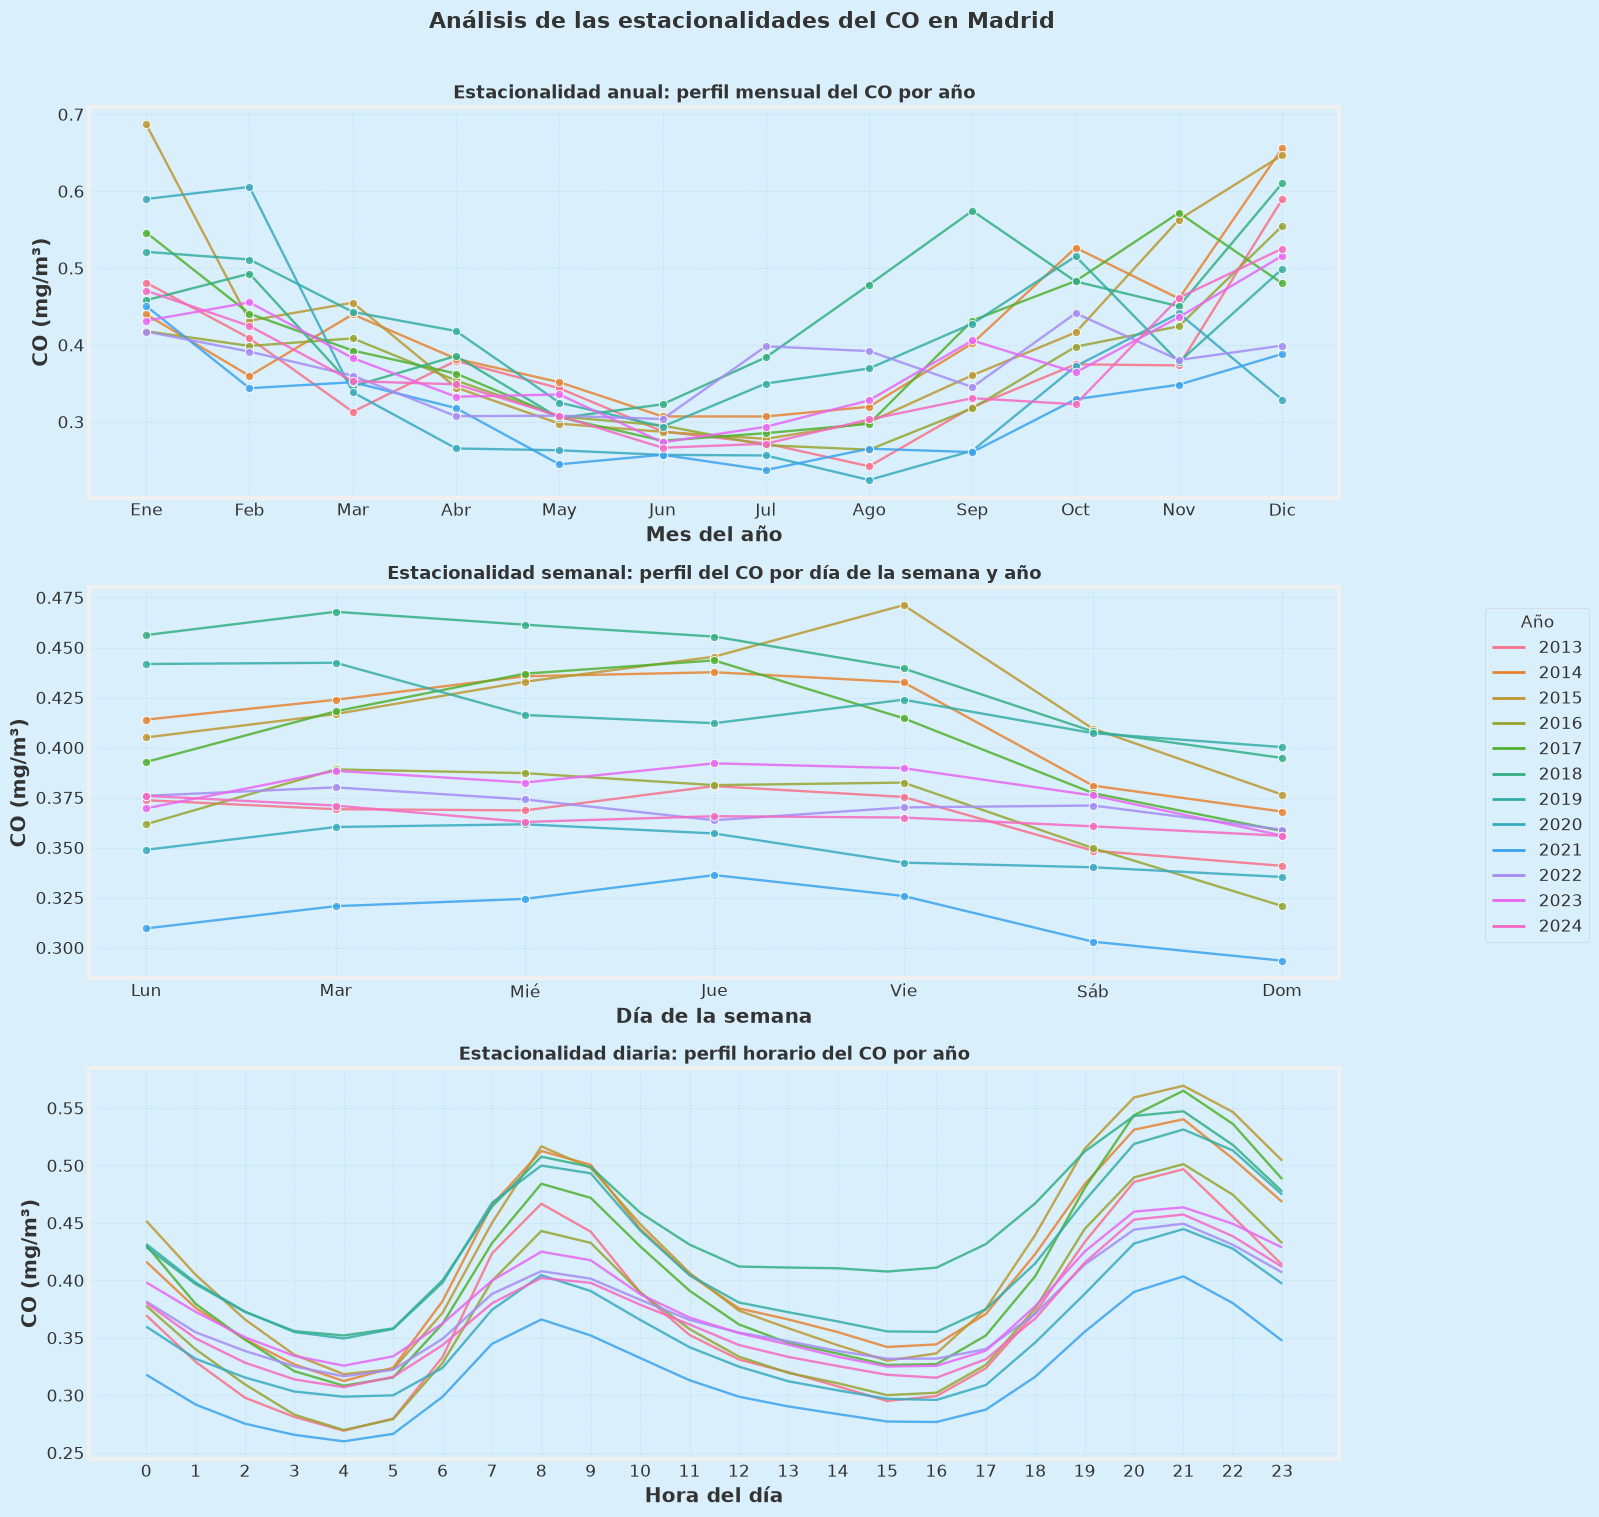

In [5]:
# Etiquetas utilizadas en los ejes
meses_nombres = [
    'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
    'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'
]

dias_nombres = [
    'Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'
]

# Años disponibles, ordenados cronológicamente
años = sorted(df1['Año'].dropna().unique())

# Paleta con un color diferente para cada año
colores = sns.color_palette('husl', n_colors=len(años))
paleta_años = dict(zip(años, colores))

# Creamos el panel con los tres perfiles estacionales
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 15)
)

# ==============================================================================
# 1. ESTACIONALIDAD ANUAL
# ==============================================================================

# Media mensual de CO calculada de manera independiente para cada año
df_mes_año = (
    df1.groupby(['Año', 'Mes'], as_index=False)['CO (mg.m-3)']
       .mean()
)

sns.lineplot(
    data=df_mes_año,
    x='Mes',
    y='CO (mg.m-3)',
    hue='Año',
    palette=paleta_años,
    marker='o',
    linewidth=1.7,
    alpha=0.85,
    ax=axes[0],
    legend=False
)

axes[0].set_title(
    'Estacionalidad anual: perfil mensual del CO por año',
    fontsize=13,
    fontweight='bold'
)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses_nombres)
axes[0].set_xlabel('Mes del año')
axes[0].set_ylabel('CO (mg/m³)')
axes[0].grid(True, linestyle=':', alpha=0.6)

# ==============================================================================
# 2. ESTACIONALIDAD SEMANAL
# ==============================================================================

# Media de CO por día de la semana calculada para cada año
df_dia_año = (
    df1.groupby(['Año', 'Dia_semana'], as_index=False)['CO (mg.m-3)']
       .mean()
)

sns.lineplot(
    data=df_dia_año,
    x='Dia_semana',
    y='CO (mg.m-3)',
    hue='Año',
    palette=paleta_años,
    marker='o',
    linewidth=1.7,
    alpha=0.85,
    ax=axes[1],
    legend=False
)

axes[1].set_title(
    'Estacionalidad semanal: perfil del CO por día de la semana y año',
    fontsize=13,
    fontweight='bold'
)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dias_nombres)
axes[1].set_xlabel('Día de la semana')
axes[1].set_ylabel('CO (mg/m³)')
axes[1].grid(True, linestyle=':', alpha=0.6)

# ==============================================================================
# 3. ESTACIONALIDAD DIARIA
# ==============================================================================

# Media horaria de CO calculada de manera independiente para cada año
df_hora_año = (
    df1.groupby(['Año', 'Hora'], as_index=False)['CO (mg.m-3)']
       .mean()
)

sns.lineplot(
    data=df_hora_año,
    x='Hora',
    y='CO (mg.m-3)',
    hue='Año',
    palette=paleta_años,
    linewidth=1.7,
    alpha=0.85,
    ax=axes[2],
    legend=False
)

axes[2].set_title(
    'Estacionalidad diaria: perfil horario del CO por año',
    fontsize=13,
    fontweight='bold'
)
axes[2].set_xticks(range(24))
axes[2].set_xlabel('Hora del día')
axes[2].set_ylabel('CO (mg/m³)')
axes[2].grid(True, linestyle=':', alpha=0.6)

# ==============================================================================
# LEYENDA COMÚN Y AJUSTES FINALES
# ==============================================================================

# Creamos una única leyenda común para los tres gráficos
leyenda = [
    plt.Line2D(
        [0],
        [0],
        color=paleta_años[año],
        linewidth=2,
        label=str(año)
    )
    for año in años
]

fig.legend(
    handles=leyenda,
    title='Año',
    bbox_to_anchor=(0.99, 0.5),
    loc='center left',
    frameon=True
)

fig.suptitle(
    'Análisis de las estacionalidades del CO en Madrid',
    fontsize=16,
    fontweight='bold',
    y=1.01
)


fig.savefig(
    FOLDER_FIGS / "estacionalidades_CO_Madrid.png",
    dpi=300,                
    bbox_inches='tight',   
    facecolor='white'     
)

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()

A partir de las gráficas obtenidas, observamos que tanto la evolución mensual como la evolución horaria de la concentración de CO presentan una forma similar entre los distintos años. En el caso de la estacionalidad anual, las concentraciones tienden a ser más elevadas durante los meses de invierno y más reducidas en los meses de verano, manteniéndose este comportamiento de forma consistente a lo largo del periodo de estudio. Por otro lado, el perfil horario muestra de manera recurrente dos máximos diarios, coincidentes con las primeras horas de la mañana y las últimas horas de la tarde, separados por un descenso durante las horas centrales del día. Además, con respecto a la evolución semanal, notamos diferencias entre los distintos años, por lo que no consideramos que haya estacionalidad semanal.

Por tanto, concluimos que la serie presenta **estacionalidad anual**, con un periodo de **un año (12 meses)**, y una **estacionalidad diaria**, con un periodo de **24 horas**.

## División del conjunto de datos

Una vez realizado el análisis exploratorio y estudiadas las principales estacionalidades de la serie temporal, procedemos a dividir el conjunto de datos en tres subconjuntos: entrenamiento, validación y prueba.

A diferencia de otros problemas de aprendizaje automático, en las series temporales no es adecuado realizar una partición aleatoria de las observaciones, ya que ello rompería la dependencia temporal existente entre los datos e introduciría información del futuro durante el entrenamiento del modelo. Por este motivo, realizamos la división respetando el orden cronológico de la serie.

Establecemos los siguientes subconjuntos:

- **Conjunto de entrenamiento:** desde **2013** hasta **2020**. Se utiliza para ajustar el modelo Prophet y estimar sus componentes de tendencia y estacionalidad.
- **Conjunto de validación:** desde **2021** hasta **2022**. Se emplea para evaluar distintas configuraciones del modelo y seleccionar los hiperparámetros que proporcionan el mejor rendimiento sin utilizar información del conjunto de prueba.
- **Conjunto de prueba:** desde **2023** hasta **2024**. Se reserva exclusivamente para la evaluación final del modelo, proporcionando una estimación objetiva de su capacidad de generalización sobre datos no utilizados durante el entrenamiento ni la validación.

In [75]:
# ==============================================================================
# División cronológica del conjunto de datos
# ==============================================================================

train = df1[df1["Año"] <= 2020].copy()

validation = df1[
    (df1["Año"] >= 2021) &
    (df1["Año"] <= 2022)
].copy()

test = df1[df1["Año"] >= 2023].copy()

print(f"Entrenamiento: {train['Start'].min()} -> {train['Start'].max()}")
print(f"Validación:    {validation['Start'].min()} -> {validation['Start'].max()}")
print(f"Prueba:        {test['Start'].min()} -> {test['Start'].max()}")

print()
print(f"Nº muestras entrenamiento: {len(train):,}")
print(f"Nº muestras validación:    {len(validation):,}")
print(f"Nº muestras prueba:        {len(test):,}")

Entrenamiento: 2013-01-01 00:00:00 -> 2020-12-31 23:00:00
Validación:    2021-01-01 00:00:00 -> 2022-12-31 23:00:00
Prueba:        2023-01-01 00:00:00 -> 2024-12-31 23:00:00

Nº muestras entrenamiento: 70,128
Nº muestras validación:    17,520
Nº muestras prueba:        17,544


Prophet espera que los datos estén formateados de una manera específica. El modelo requiere una columna *ds* que contenga las fechas y una columna *y* que contenga los valores que queremos modelar/predecir.

In [76]:
train = train.rename(columns={"Start": "ds", "CO (mg.m-3)": "y"})
validation = validation.rename(columns={"Start": "ds", "CO (mg.m-3)": "y"})
test = test.rename(columns={"Start": "ds", "CO (mg.m-3)": "y"})

## Métricas de evaluación

Para evaluar la capacidad predictiva del modelo, empleamos diferentes métricas de error, ya que cada una proporciona información complementaria sobre la diferencia entre las concentraciones reales y las estimadas.

- **Error absoluto medio (MAE):** representa la magnitud media de los errores en las mismas unidades que la variable objetivo. Al utilizar valores absolutos, todos los errores reciben el mismo peso.

- **Error cuadrático medio (MSE):** calcula el promedio de los errores elevados al cuadrado. Esta métrica penaliza en mayor medida las predicciones que se alejan considerablemente de los valores reales.

- **Raíz del error cuadrático medio (RMSE):** corresponde a la raíz cuadrada del MSE. Mantiene la penalización de los errores elevados, pero expresa el resultado en las mismas unidades que la concentración de CO.

- **Error porcentual absoluto medio (MAPE):** expresa el error medio de las predicciones en términos porcentuales respecto a los valores reales. Esta métrica facilita la interpretación relativa del error. No obstante, puede resultar inestable cuando los valores reales son iguales o muy próximos a cero. Por este motivo, para su cálculo se excluyen las observaciones cuyo valor real de CO sea exactamente cero.

- **Coeficiente de determinación ajustado ($R^2_{\text{ajustado}}$):** representa una corrección del coeficiente de determinación que tiene en cuenta tanto el número de observaciones como el número de parámetros incluidos en el modelo. A diferencia del $R^2$, penaliza la incorporación de parámetros adicionales que no produzcan una mejora suficiente en la capacidad explicativa del modelo.

El análisis conjunto de estas métricas permite evaluar tanto la magnitud media de los errores como la presencia de errores especialmente elevados y la capacidad general del modelo para reproducir la variabilidad de la serie temporal.

In [77]:
def evaluar_metricas(y_real, y_predicho, num_parametros):
    """
    Calcula y muestra las principales métricas de evaluación
    de un modelo de predicción.

    Parámetros
    ----------
    y_real : array-like
        Valores reales de la variable objetivo.

    y_predicho : array-like
        Valores estimados por el modelo.

    num_parametros : int
        Número de parámetros o variables explicativas utilizados
        para calcular el coeficiente de determinación ajustado.

    Retorna
    -------
    dict
        Diccionario con MAE, MSE, RMSE, MAPE, R² y R² ajustado.
    """

    # Número de observaciones
    n = len(y_real)

    # Cálculo de las métricas
    mae = metrics.mean_absolute_error(y_real, y_predicho)
    mse = metrics.mean_squared_error(y_real, y_predicho)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(y_real, y_predicho)

    # Coeficiente de determinación ajustado
    r2_ajustado = 1 - (
        (1 - r2) * (n - 1) / (n - num_parametros - 1)
    )

    def MAPE(y_true, y_pred):
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    mape = MAPE(y_real, y_predicho)

    # Resultados
    resultados = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2,
        'R2_ajustado': r2_ajustado
    }

    # Mostramos los resultados
    print('Resultados de la evaluación del modelo')
    print('---------------------------------------')
    print(f'Error absoluto medio (MAE): {mae:.6f}')
    print(f'Error cuadrático medio (MSE): {mse:.6f}')
    print(f'Raíz del error cuadrático medio (RMSE): {rmse:.6f}')
    print(f'Error porcentual absoluto medio (MAPE): {mape:.2f} %')
    print(
        f'Coeficiente de determinación ajustado (R² ajustado): '
        f'{r2_ajustado:.6f}'
    )

    return resultados

## Elección de variables exógenas

En la matriz de correlaciones para Madrid del EDA, ya vimos que el CO está correlacionado positivamente con No, NO2, NOx y C6H6, y esta están correlacionadas con otras variables atmosférica. Por tanto, realizamos el estudio de la multicolinealidad entre variables. Para ello, aplicamos el cálculo del VIF, que tiene por interpretación: 

- VIF cercano a 1: poca dependencia lineal.
- VIF entre 5 y 10: multicolinealidad apreciable.
- VIF superior a 10: multicolinealidad elevada.

In [78]:
def calcular_vif(datos, variables):
    """
    Calcula el factor de inflación de la varianza de un conjunto
    de variables explicativas.
    """

    X = datos[variables].replace([np.inf, -np.inf], np.nan)

    # Imputación mediante la mediana, únicamente para calcular el VIF
    imputador = SimpleImputer(strategy="median")
    X_imputado = imputador.fit_transform(X)

    # Estandarización de las variables
    escalador = StandardScaler()
    X_escalado = escalador.fit_transform(X_imputado)

    vif = pd.DataFrame({
        "variable": variables,
        "VIF": [
            variance_inflation_factor(X_escalado, i)
            for i in range(X_escalado.shape[1])
        ]
    })

    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)


In [ ]:
multi = [
    "y",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "surface_pressure",
    "cloudcover",
    "windspeed_10m",
    "shortwave_radiation",
    "boundary_layer_height",
    "NDVI",
    "NDBI"
]

vif_exogenas = calcular_vif(
    datos=train,
    variables=multi
)

vif_exogenas

,variable,VIF
0,precipitation,214031.678344
1,rain,211661.686178
2,snowfall,1054.786157
3,relative_humidity_2m,4.037476
4,boundary_layer_height,3.583951
5,temperature_2m,3.565652
6,shortwave_radiation,2.883708
7,windspeed_10m,1.436770
8,surface_pressure,1.371546
9,NDVI,1.356917


Observamos que existe una muy alta multicolinealidad entre entre `precipitation`, `rain` y `snowfall`. Habitualmente, la precipitación total se construye a partir de la lluvia y la nieve, de forma aproximada:

$$ precipitation≈rain+snowfall $$

Por tanto, no incorporaremos simultáneamente las tres variables al modelo. Probamos eliminando las variables`rain` y `snowfall`.

In [ ]:
variables_exogenas1 = [
    "y",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "surface_pressure",
    "cloudcover",
    "windspeed_10m",
    "shortwave_radiation",
    "boundary_layer_height",
    "NDVI",
    "NDBI"
]

In [ ]:
multi1 = calcular_vif(
    datos=train,
    variables=variables_exogenas1
)

multi1

,variable,VIF
0,relative_humidity_2m,4.035208
1,boundary_layer_height,3.583919
2,temperature_2m,3.558815
3,shortwave_radiation,2.883591
4,windspeed_10m,1.436680
5,surface_pressure,1.370916
6,NDVI,1.356701
7,cloudcover,1.352473
8,precipitation,1.143587
9,NDBI,1.079160


In [ ]:
variables_exogenas1 = multi1.copy()
variables_exogenas1.remove("y")

Observamos que ya no tenemos problemas de multicolinealidad, por lo que estas serán las variables exógenas que emplearemos.

## Selección de los mejores hiperparámetros

Una vez definidos los conjuntos de entrenamiento, validación y prueba, continuamos seleccionando la configuración más adecuada del modelo **Prophet**. Para ello, ajustamos el modelo utilizando exclusivamente las observaciones del conjunto de entrenamiento, correspondientes al periodo comprendido entre 2013 y 2020, y se evalúa sobre el conjunto de validación, formado por los años 2021 y 2022.

LLevamos a cabo la selección de los hiperparámetros mediante la comparación de diferentes configuraciones del modelo. Para cada combinación, Prophet se entrena con el conjunto de entrenamiento y genera predicciones para las fechas del conjunto de validación. Posteriormente, se calcula el error MSE entre los valores reales y las predicciones obtenidas. La configuración seleccionada será aquella que presente el menor MSE sobre el conjunto de validación.

De acuerdo con el análisis exploratorio realizado previamente, todos los modelos incorporan simultáneamente una estacionalidad anual y una estacionalidad diaria, mientras que la estacionalidad semanal no se incluye. Además, se evalúan modelos con y sin los días festivos nacionales de España, con el objetivo de comprobar si los cambios de movilidad y actividad asociados a estas fechas mejoran la capacidad predictiva del modelo.

También, incorporamos como regresores externos diferentes variables meteorológicas y ambientales que pueden influir en la concentración de CO. Tras analizar la multicolinealidad mediante el factor de inflación de la varianza, excluimos las variables `rain` y `snowfall`, debido a su elevada redundancia con la precipitación total. En consecuencia, hacemos uso de las siguientes variables exógenas:

- Temperatura a dos metros.
- Humedad relativa a dos metros.
- Precipitación total.
- Presión en superficie.
- Nubosidad.
- Velocidad del viento a diez metros.
- Radiación solar de onda corta.
- Altura de la capa límite planetaria.
- Índice de vegetación de diferencia normalizada, NDVI.
- Índice de edificación de diferencia normalizada, NDBI.

Las variables exógenas se incluyen en todas las configuraciones evaluadas. De este modo, la búsqueda se centra en determinar la configuración de tendencia, estacionalidad, crecimiento y festivos que mejor aprovecha la información temporal y ambiental disponible.

Los principales hiperparámetros evaluados son:

- El número de puntos de cambio de la tendencia, mediante `n_changepoints`.
- La proporción inicial de la serie en la que se sitúan los puntos de cambio, mediante `changepoint_range`.
- La flexibilidad de la tendencia, mediante `changepoint_prior_scale`.
- La intensidad de las componentes estacionales, mediante `seasonality_prior_scale`.
- El tipo de combinación de las componentes, mediante `seasonality_mode`.
- El tipo de crecimiento de la tendencia, lineal o logístico, mediante `growth`.
- El número de términos de Fourier utilizados para representar las estacionalidades anual y diaria.
- La incorporación o no de los días festivos nacionales de España.
- La intensidad del efecto de los festivos, mediante `holidays_prior_scale`.

Nos quedamos exclusivamente con las variables necesarias para el modelado.

In [ ]:
# Lista de columnas que quieres mantener
columnas = ['ds', 'y'] + variables_exogenas1

train = train[columnas]
validation = validation[columnas]

### Definición del espacio de búsqueda

Como los datos tienen una frecuencia horaria y el conjunto de entrenamiento contiene varios años, una búsqueda exhaustiva de todas las combinaciones posibles podría requerir un tiempo de ejecución elevado. Por este motivo, realizamos una búsqueda aleatoria sobre un número determinado de configuraciones del espacio de hiperparámetros.

Este procedimiento no corresponde a una validación cruzada temporal. Cada configuración se ajusta una única vez utilizando el conjunto de entrenamiento de 2013 a 2020 y se evalúa siempre sobre el conjunto de validación de 2021 y 2022. De esta manera, se respeta el orden cronológico de las observaciones y se evita utilizar información futura durante el entrenamiento.

Todas las configuraciones incluyen simultáneamente la estacionalidad anual, la estacionalidad diaria y las variables exógenas seleccionadas. La estacionalidad semanal permanece desactivada. La incorporación de los festivos nacionales de España se considera como una alternativa dentro del espacio de búsqueda.

In [ ]:
# ==============================================================================
# Valores candidatos de los hiperparámetros
# ==============================================================================

param_grid = {
    
    # Flexibilidad de la tendencia
    "changepoint_prior_scale": [
        0.005,
        0.05,
        0.5
    ],

    # Parte inicial de la serie en la que se colocan los puntos de cambio
    "changepoint_range": [
        0.70,
        0.80,
        0.90
    ],

    # Intensidad de las estacionalidades
    "seasonality_prior_scale": [
        0.05,
        1.0
    ],

    # Tipo de estacionalidad
    "seasonality_mode": [
       "additive",
        "multiplicative"
    ],

    # Tipo de crecimiento
    "growth": [
       "linear",
        "logistic"
    ],

    # Número de términos de Fourier de la estacionalidad anual
    "yearly_seasonality": [
        5,
        10,
        20
    ],

    # Número de términos de Fourier de la estacionalidad diaria
    "daily_seasonality": [
        5,
        10,
        20
    ],

    # Incorporación de festivos nacionales de España
    "usar_festivos": [
        False,
        True
    ]
}

### Búsqueda del mejor modelo

Para cada configuración de hiperparámetros se crea un modelo Prophet al que se añaden las variables exógenas seleccionadas. A continuación, el modelo se ajusta utilizando el conjunto de entrenamiento y genera predicciones para las fechas y los valores de los regresores del conjunto de validación.

En las configuraciones con crecimiento logístico es necesario establecer una capacidad máxima mediante la columna `cap`. Esta capacidad se define ligeramente por encima del máximo de CO observado en el conjunto de entrenamiento. También se establece un límite inferior igual a cero mediante la columna `floor`, debido a que la concentración de CO no puede adoptar valores físicamente negativos.

Tanto la capacidad como el resto de decisiones de preparación se calculan exclusivamente a partir del conjunto de entrenamiento, evitando utilizar información procedente del conjunto de validación.

Finalmente, se calcula el error cuadrático medio de cada configuración sobre el conjunto de validación. La configuración con el menor MSE será seleccionada como la más adecuada.

In [102]:
# ==============================================================================
# Límites para los modelos con crecimiento logístico
# ==============================================================================

capacidad = train["y"].max() * 1.20

print(
    "Capacidad utilizada para el crecimiento logístico: "
    f"{capacidad:.6f}"
)

Capacidad utilizada para el crecimiento logístico: 3.816000


In [107]:
# ==============================================================================
# Generación de todas las combinaciones posibles
# ==============================================================================

configuraciones = list(
    ParameterGrid(param_grid)
)

print(
    f"Número total de configuraciones que se evaluarán: "
    f"{len(configuraciones)}"
)

Número total de configuraciones que se evaluarán: 1


In [ ]:
# ==============================================================================
# Ajuste y evaluación de las diferentes configuraciones
# ==============================================================================

resultados_busqueda = []

for params in configuraciones:

    # Extraemos el indicador de utilización de festivos, ya que no es
    # un hiperparámetro que se pase directamente al constructor de Prophet
    usar_festivos = params["usar_festivos"]

    # Seleccionamos únicamente los parámetros admitidos por Prophet
    parametros_modelo = {
        "changepoint_prior_scale": params["changepoint_prior_scale"],
        "changepoint_range": params["changepoint_range"],
        "seasonality_prior_scale": params["seasonality_prior_scale"],
        "seasonality_mode": params["seasonality_mode"],
        "growth": params["growth"],
        "yearly_seasonality": params["yearly_seasonality"],
        "daily_seasonality": params["daily_seasonality"]
    }

    try:
        # ----------------------------------------------------------------------
        # Creación del modelo
        # ----------------------------------------------------------------------
        modelo = Prophet(
            **parametros_modelo,
            weekly_seasonality=False
        )

        # ----------------------------------------------------------------------
        # Incorporación de las variables exógenas
        # ----------------------------------------------------------------------
        for variable in variables_exogenas1:
            modelo.add_regressor(
                variable,
                standardize=True
            )

        # ----------------------------------------------------------------------
        # Incorporación de los festivos nacionales de España
        # ----------------------------------------------------------------------
        if usar_festivos:
            modelo.add_country_holidays(
                country_name="ES"
            )

        # ----------------------------------------------------------------------
        # Copia de los conjuntos de entrenamiento y validación
        # ----------------------------------------------------------------------
        datos_entrenamiento = train.copy()
        datos_validacion = validation.copy()

        # ----------------------------------------------------------------------
        # Límites requeridos por el crecimiento logístico
        # ----------------------------------------------------------------------
        if params["growth"] == "logistic":
            datos_entrenamiento["cap"] = capacidad
            datos_entrenamiento["floor"] = 0

            datos_validacion["cap"] = capacidad
            datos_validacion["floor"] = 0

        # ----------------------------------------------------------------------
        # Entrenamiento del modelo
        # ----------------------------------------------------------------------
        modelo.fit(datos_entrenamiento)

        # ----------------------------------------------------------------------
        # Preparación de los datos para la predicción
        # ----------------------------------------------------------------------
        columnas_prediccion = [
            "ds"
        ] + variables_exogenas1

        if params["growth"] == "logistic":
            columnas_prediccion += [
                "cap",
                "floor"
            ]

        fechas_validacion = datos_validacion[
            columnas_prediccion
        ].copy()

        # ----------------------------------------------------------------------
        # Predicción sobre el conjunto de validación
        # ----------------------------------------------------------------------
        prediccion = modelo.predict(
            fechas_validacion
        )

        # ----------------------------------------------------------------------
        # Cálculo del error cuadrático medio
        # ----------------------------------------------------------------------
        mse = mean_squared_error(
            datos_validacion["y"],
            prediccion["yhat"]
        )

        # ----------------------------------------------------------------------
        # Almacenamiento del resultado
        # ----------------------------------------------------------------------
        resultado = params.copy()
        resultado["MSE_validacion"] = mse
        resultado["estado"] = "Correcto"

        resultados_busqueda.append(resultado)

    except Exception as error:

        resultado = params.copy()
        resultado["MSE_validacion"] = np.nan
        resultado["estado"] = str(error)

        resultados_busqueda.append(resultado)


# ==============================================================================
# Selección de la mejor configuración
# ==============================================================================

resultados_df = pd.DataFrame(resultados_busqueda)

resultados_correctos = resultados_df[
    resultados_df["estado"] == "Correcto"
].copy()

resultados_correctos = resultados_correctos.sort_values(
    by="MSE_validacion",
    ascending=True
).reset_index(drop=True)

mejor_resultado = resultados_correctos.iloc[0]

print("Mejores parámetros:\n")

for parametro in param_grid.keys():
    print(f"{parametro}: {mejor_resultado[parametro]}")

print(
    f"\nMSE de validación: "
    f"{mejor_resultado['MSE_validacion']:.8f}"
)

Estacionalidades utilizadas:
- yearly
- daily

Mejores parámetros:

changepoint_prior_scale: 0.5
changepoint_range: 0.9
seasonality_prior_scale: 1.0
seasonality_mode: multiplicative
growth: logistic
usar_festivos: True
yearly_seasonality: 20
daily_seasonality: 20

MSE de validación: 0.01771497


Así, obtenemos el mejor modelo Prophet para el contaminante CO en Madrid. Veamos todas sus métricas de error sobre el conjunto de validación.

In [ ]:
# ==============================================================================
# Modelo Prophet con los mejores hiperparámetros
# ==============================================================================

# Capacidad calculada únicamente con los datos de entrenamiento
capacidad = train["y"].max() * 1.20

# Copiamos los conjuntos para no modificar los originales
train_prophet_final = train.copy()
validation_prophet_final = validation.copy()

# Al utilizar crecimiento logístico, Prophet necesita cap y floor
train_prophet_final["cap"] = capacidad
train_prophet_final["floor"] = 0

validation_prophet_final["cap"] = capacidad
validation_prophet_final["floor"] = 0


# ==============================================================================
# Creación del modelo
# ==============================================================================

modelo_prophet = Prophet(
    changepoint_prior_scale=0.5,
    changepoint_range=0.7,
    seasonality_prior_scale=1.0,
    seasonality_mode="multiplicative",
    growth="logistic",
    yearly_seasonality=20,
    daily_seasonality=20
)

# ==============================================================================
# Incorporación de las variables exógenas
# ==============================================================================

for variable in variables_exogenas1:
    modelo_prophet.add_regressor(
        variable,
        standardize=True
    )

# ==============================================================================
# Incorporación de los festivos nacionales de España
# ==============================================================================

modelo_prophet.add_country_holidays(
    country_name="ES"
)


# ==============================================================================
# Entrenamiento del modelo
# ==============================================================================

modelo_prophet.fit(
    train_prophet_final
)


# ==============================================================================
# Preparación de los datos de validación
# ==============================================================================

columnas_prediccion = (
    ["ds"]
    + variables_exogenas1
    + ["cap", "floor"]
)

fechas_validacion = validation_prophet_final[
    columnas_prediccion
].copy()

# ==============================================================================
# Predicción sobre el conjunto de validación
# ==============================================================================

prediccion_validacion = modelo_prophet.predict(
    fechas_validacion
)

# ==============================================================================
# Evaluación del modelo
# ==============================================================================

# Número de variables exógenas utilizadas
num_parametros = len(variables_exogenas1)

metricas_validacion = evaluar_metricas(
    y_real=validation_prophet_final["y"],
    y_predicho=prediccion_validacion["yhat"],
    num_parametros=num_parametros
)

Resultados de la evaluación del modelo
---------------------------------------
Error absoluto medio (MAE): 0.077939
Error cuadrático medio (MSE): 0.01771497
Raíz del error cuadrático medio (RMSE): 0.133097
Error porcentual absoluto medio (MAPE): 12.13 %
